# 批量规范化
---
## 环境配置

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import numpy as np
import pypto
import torch
import torch_npu
import torchvision
from torch import nn
device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOAvgPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear
from src.D2LFunction import *
from src.AnswerUtlis import *
from src import Models
import torchinfo

---
## 练习 7.5.1

在使用批量规范化之前，我们是否可以完全省略全连接层或卷积层的偏置参数？为什么？

### 解答

&emsp;&emsp;可以。批量规范化层引入了可学习的 $\gamma$ 与 $\beta$ 参数，其中 $\beta$ 起到了偏置的作用，因此原始的偏置项 $b$ 可以省略。

---
## 练习 7.5.2

比较LeNet在使用和不使用批量规范化情况下的学习率。
1. 记录训练和测试精度的提升。
1. 学习率可以多高？

### 解答

&emsp;&emsp;首先加载必要的库、训练函数并加载图像。

**第1问：**

&emsp;&emsp;批量规范化通过规范化层让训练更稳定、能适应更高的学习率，从而加快训练收敛速度。

使用 `torch` 编程进行验证：

**训练:**

In [2]:
import os
pth = '../data/ch07_output/'
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 torch 版 LeNet 与 LeNet_BN 训练 (各 20 epochs @28)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则, torch 版训练全部注释;
# 仅保留 pth 定义 (供画图 cell 使用)。
# 如需恢复 torch 训练: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# LeNet = Models.LeNet()
# LeNet_BN = Models.LeNet_BN()
# batch_size, lr = 128, 0.9
# train_loader, test_loader = load_data_fashion_mnist(batch_size)
# train_models(LeNet, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet', csv_prefix='ch7_05')
# train_models(LeNet_BN, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_BN', csv_prefix='ch7_05')

**展示:**

In [3]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 torch 版 LeNet/LeNet_BN 曲线, 依赖 ccode[1] 的
#   torch 训练产出 CSV 列, 该训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[1] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(pth = os.path.join(pth, 'ch7_05.csv'),
#              label_list=[('LeNet_epoch_train', 'LeNet_train_loss'),
#                          ('LeNet_BN_epoch_train', 'LeNet_BN_train_loss')],
#              title='the loss of LeNet vs LeNet_BN')
# draw_figures(pth = os.path.join(pth, 'ch7_05_eval.csv'),
#              label_list=[('LeNet_epoch_test', 'LeNet_test_acc'),
#                          ('LeNet_BN_epoch_test', 'LeNet_BN_test_acc')],
#              title='the acc of LeNet vs LeNet_BN')

使用 `PyPTO` 编程进行验证：

**训练:**

In [4]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 LeNet_pypto 与 LeNet_BN_pypto 两个训练
#   (各 20 epochs @28, lr=0.9, batch=128)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则, 仅保留 LeNet_pypto
#   完整训练 (本 notebook 保留的 PyPTO 训练)。
# 如需恢复 LeNet_BN_pypto 训练: 取消下方 3 行注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
LeNet_pypto = Models.LeNet_pypto(device=device)
train_loader, test_loader = load_data_fashion_mnist(128)
train_models(LeNet_pypto, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_pypto', csv_prefix='ch7_05', device=device)
# LeNet_BN_pypto = Models.LeNet_BN_pypto()
# train_loader, test_loader = load_data_fashion_mnist(128)
# train_models(LeNet_BN_pypto, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_BN_pypto', csv_prefix='ch7_05')

[LeNet_pypto] 训练完成: train_loss=0.2989 ██████░░ train_acc=0.8880 ███████░ test_acc=0.8728 ███████░ et=05:43


**展示:**

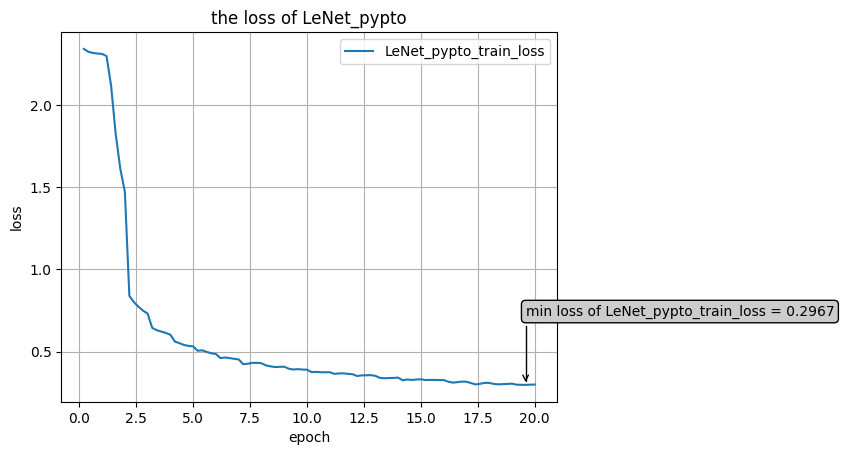

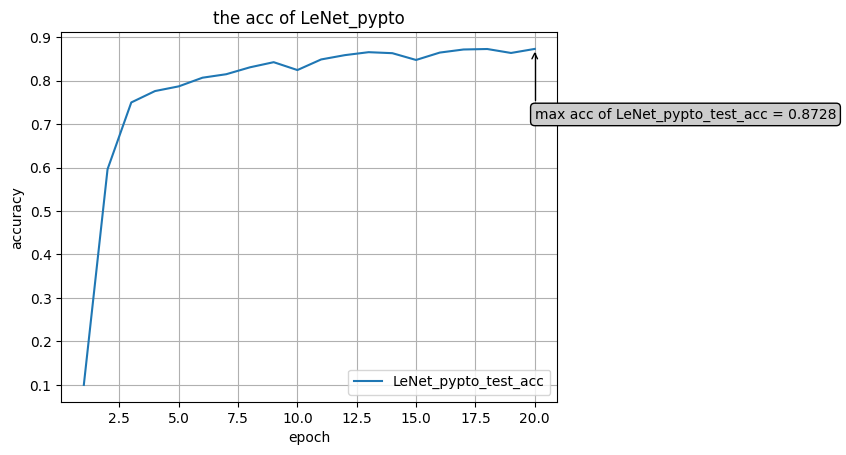

In [5]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 label_list 含 LeNet_pypto 与 LeNet_BN_pypto 两条曲线,
#   LeNet_BN_pypto 训练已注释 (ccode[3]), 仅保留 LeNet_pypto 的
#   train_loss 与 test_acc 两列。
# 如需恢复: 恢复 ccode[3] 的 LeNet_BN_pypto 训练后, 恢复原 label_list。
# ══════════════════════════════════════════════════════════════════════
draw_figures(pth = os.path.join(pth, 'ch7_05.csv'),
             label_list=[('LeNet_pypto_epoch_train', 'LeNet_pypto_train_loss')],
             title='the loss of LeNet_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_05_eval.csv'),
             label_list=[('LeNet_pypto_epoch_test', 'LeNet_pypto_test_acc')],
             title='the acc of LeNet_pypto')

**第2问：**

&emsp;&emsp;通过对比不同学习率下的准确率变化，可以看到 BN 模型可以承受更高的学习率。

使用 `torch` 编程进行验证：

In [6]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 torch 版 LeNet / LeNet_BN 的 lr sweep (lr_list 19 个
#   学习率 × 2 模型 = 38 个训练, 各 10 epochs)。与保留训练 (LeNet_pypto 20ep)
#   行数不同导致 write2csv 报 ValueError, 且全跑耗时大。
# 按验证模式原则全部注释。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# max_acc_LeNet = []
# max_acc_LeNet_BN = []
# lr_list = [0.7 + i * 0.1 * 0.2 for i in range(int((10 - 1) / 0.5) + 1)]
# for lr in lr_list:
#     LeNet = Models.LeNet()
#     train_loader, test_loader = load_data_fashion_mnist(128)
#     train_models(LeNet, train_loader, test_loader, epochs=10, lr=lr, net_type=f'LeNet_lr{lr:.2f}', csv_prefix='ch7_05')
# for lr in lr_list:
#     LeNet_BN = Models.LeNet_BN()
#     train_loader, test_loader = load_data_fashion_mnist(128)
#     train_models(LeNet_BN, train_loader, test_loader, epochs=10, lr=lr, net_type=f'LeNet_BN_lr{lr:.2f}', csv_prefix='ch7_05')
# print('lr sweep done')

---
## 练习 7.5.3

我们是否需要在每个层中进行批量规范化？尝试一下。

### 解答

&emsp;&emsp;一般来说，`BatchNorm` 通常在卷积层或全连接层之后使用，也可以在激活函数之前或之后。但并非所有层都需要 `BatchNorm`，过度使用会增加参数量与计算成本。

使用 `torch` 编程进行验证：

**训练:**

In [7]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 torch 版 LeNet_BN2 与 LeNet_all_BN 训练 (各 20 epochs)。
# torch 版训练全部注释 (见 ccode[1] 注释块说明)。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# LeNet_BN2 = Models.LeNet_BN2()
# LeNet_all_BN = Models.LeNet_all_BN()
# batch_size, lr = 128, 0.9
# train_loader, test_loader = load_data_fashion_mnist(batch_size)
# train_models(LeNet_BN2, train_loader, test_loader, epochs=20, lr=lr, net_type='LeNet_BN2', csv_prefix='ch7_05')
# train_models(LeNet_all_BN, train_loader, test_loader, epochs=20, lr=lr, net_type='LeNet_all_BN', csv_prefix='ch7_05')

**展示:**

In [8]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 torch 版 BN 变体曲线 (LeNet_BN/LeNet_BN2/LeNet_all_BN),
#   依赖的 torch 训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[6] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(pth = os.path.join(pth, 'ch7_05.csv'),
#              label_list=[('LeNet_BN_epoch_train', 'LeNet_BN_train_loss'),
#                          ('LeNet_BN2_epoch_train', 'LeNet_BN2_train_loss'),
#                          ('LeNet_all_BN_epoch_train', 'LeNet_all_BN_train_loss')],
#              title='the loss of different LeNet_BN variants')
# draw_figures(pth = os.path.join(pth, 'ch7_05_eval.csv'),
#              label_list=[('LeNet_BN_epoch_test', 'LeNet_BN_test_acc'),
#                          ('LeNet_BN2_epoch_test', 'LeNet_BN2_test_acc'),
#                          ('LeNet_all_BN_epoch_test', 'LeNet_all_BN_test_acc')],
#              title='the acc of different LeNet_BN variants')

使用 `PyPTO` 编程进行验证：

**训练:**

In [9]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 PyPTO 版 LeNet_BN2_pypto 与 LeNet_all_BN_pypto 训练
#   (各 20 epochs)。按"每 notebook 保留 1 个完整 PyPTO 训练"原则注释
#   (保留训练为 ccode[3] 的 LeNet_pypto)。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# LeNet_BN2_pypto = Models.LeNet_BN2_pypto()
# LeNet_all_BN_pypto = Models.LeNet_all_BN_pypto()
# train_loader, test_loader = load_data_fashion_mnist(128)
# train_models(LeNet_BN2_pypto, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_BN2_pypto', csv_prefix='ch7_05')
# train_models(LeNet_all_BN_pypto, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_all_BN_pypto', csv_prefix='ch7_05')

**展示:**

In [10]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 PyPTO 版 BN 变体曲线 (LeNet_BN_pypto/LeNet_BN2_pypto/
#   LeNet_all_BN_pypto), 依赖的 PyPTO 训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[8] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(pth = os.path.join(pth, 'ch7_05.csv'),
#              label_list=[('LeNet_BN_pypto_epoch_train', 'LeNet_BN_pypto_train_loss'),
#                          ('LeNet_BN2_pypto_epoch_train', 'LeNet_BN2_pypto_train_loss'),
#                          ('LeNet_all_BN_pypto_epoch_train', 'LeNet_all_BN_pypto_train_loss')],
#              title='the loss of different LeNet_BN_pypto variants')
# draw_figures(pth = os.path.join(pth, 'ch7_05_eval.csv'),
#              label_list=[('LeNet_BN_pypto_epoch_test', 'LeNet_BN_pypto_test_acc'),
#                          ('LeNet_BN2_pypto_epoch_test', 'LeNet_BN2_pypto_test_acc'),
#                          ('LeNet_all_BN_pypto_epoch_test', 'LeNet_all_BN_pypto_test_acc')],
#              title='the acc of different LeNet_BN_pypto variants')

---
## 练习 7.5.4

可以使用批量规范化来代替暂退法吗？会如何改变行为？

### 解答

&emsp;&emsp;可以，但不建议同时使用。批量规范化和暂退法实现机制不同：BN 通过规范化激活值稳定训练；Dropout 通过随机丢弃神经元防止过拟合。两者目标不同，可以单独使用或组合使用，但通常单独使用 BN 已经足够稳定。

使用 `torch` 编程进行验证：

In [11]:
dropout = nn.Dropout(0.5)
batchnorn = nn.BatchNorm2d(1)
x = torch.rand(1, 1, 3, 3)
print('dropout(x):', dropout(x))
print('batchnorn(x):', batchnorn(x))

dropout(x): tensor([[[[0.0000, 1.6862, 0.8388],
          [0.0000, 0.7966, 1.5724],
          [0.2830, 0.0000, 0.0961]]]])
batchnorn(x): tensor([[[[ 0.0453,  0.9005, -0.4536],
          [ 1.3369, -0.5211,  0.7185],
          [-1.3419,  0.9559, -1.6404]]]], grad_fn=<NativeBatchNormBackward0>)


---
## 练习 7.5.5

确定参数`beta`和`gamma`并观察结果。

### 解答

&emsp;&emsp;可以通过自定义 `BatchNorm` (如 Models.BatchNorm_pypto) 并设置 `freeze=True` 固定 $\beta$ 与 $\gamma$，观察对训练过程的影响。

使用 `torch` 编程进行验证：

**训练:**

In [12]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    if not torch.is_grad_enabled():
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        X_hat = (X - mean) / torch.sqrt(var + eps)
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta
    return Y, moving_mean.data, moving_var.data

# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 在 batch_norm 函数定义后还有 torch 版 LeNet_BN_freeze 与
#   LeNet_BN2_freeze 训练 (各 20 epochs)。按验证模式原则, 训练部分注释,
#   仅保留 batch_norm 函数定义 (教学内容)。
# 如需恢复 freeze 训练: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# LeNet_BN_freeze = Models.LeNet_BN_freeze()
# LeNet_BN2_freeze = Models.LeNet_BN2_freeze()
# batch_size, lr = 128, 0.9
# train_loader, test_loader = load_data_fashion_mnist(batch_size)
# train_models(LeNet_BN_freeze, train_loader, test_loader, epochs=20, lr=lr, net_type='LeNet_BN_freeze', csv_prefix='ch7_05')
# train_models(LeNet_BN2_freeze, train_loader, test_loader, epochs=20, lr=lr, net_type='LeNet_BN2_freeze', csv_prefix='ch7_05')

**展示:**

In [13]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 torch 版 freeze 变体曲线 (LeNet_BN_freeze/
#   LeNet_BN2_freeze), 依赖的 torch 训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[11] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(pth = os.path.join(pth, 'ch7_05.csv'),
#              label_list=[('LeNet_BN_freeze_epoch_train', 'LeNet_BN_freeze_train_loss'),
#                          ('LeNet_BN2_freeze_epoch_train', 'LeNet_BN2_freeze_train_loss')],
#              title='the loss of LeNet_BN_freeze variants')
# draw_figures(pth = os.path.join(pth, 'ch7_05_eval.csv'),
#              label_list=[('LeNet_BN_freeze_epoch_test', 'LeNet_BN_freeze_test_acc'),
#                          ('LeNet_BN2_freeze_epoch_test', 'LeNet_BN2_freeze_test_acc')],
#              title='the acc of LeNet_BN_freeze variants')

使用 `PyPTO` 编程进行验证：

**训练:**

In [14]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 PyPTO 版 LeNet_BN_freeze_pypto 与 LeNet_BN2_freeze_pypto
#   训练 (各 20 epochs)。按"每 notebook 保留 1 个完整 PyPTO 训练"原则注释
#   (保留训练为 ccode[3] 的 LeNet_pypto)。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# LeNet_BN_freeze_pypto = Models.LeNet_BN_freeze_pypto()
# LeNet_BN2_freeze_pypto = Models.LeNet_BN2_freeze_pypto()
# train_loader, test_loader = load_data_fashion_mnist(128)
# train_models(LeNet_BN_freeze_pypto, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_BN_freeze_pypto', csv_prefix='ch7_05')
# train_models(LeNet_BN2_freeze_pypto, train_loader, test_loader, epochs=20, lr=0.9, net_type='LeNet_BN2_freeze_pypto', csv_prefix='ch7_05')

**展示:**

In [15]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 PyPTO 版 freeze 变体曲线 (LeNet_BN_freeze_pypto/
#   LeNet_BN2_freeze_pypto), 依赖的 PyPTO 训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[13] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(pth = os.path.join(pth, 'ch7_05.csv'),
#              label_list=[('LeNet_BN_freeze_pypto_epoch_train', 'LeNet_BN_freeze_pypto_train_loss'),
#                          ('LeNet_BN2_freeze_pypto_epoch_train', 'LeNet_BN2_freeze_pypto_train_loss')],
#              title='the loss of LeNet_BN_freeze_pypto variants')
# draw_figures(pth = os.path.join(pth, 'ch7_05_eval.csv'),
#              label_list=[('LeNet_BN_freeze_pypto_epoch_test', 'LeNet_BN_freeze_pypto_test_acc'),
#                          ('LeNet_BN2_freeze_pypto_epoch_test', 'LeNet_BN2_freeze_pypto_test_acc')],
#              title='the acc of LeNet_BN_freeze_pypto variants')

---
## 练习 7.5.6

查看高级API中有关`BatchNorm`的文档以查看有关其应用的更多信息。

### 解答

&emsp;&emsp;详见 PyTorch 官方文档：
- [BatchNorm1d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- [BatchNorm2d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)
- [BatchNorm3d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm3d.html)

---
## 练习 7.5.7

研究思路：能否将完全连接层替换为全局协方差池化？这会导致什么样的结果？

### 解答

&emsp;&emsp;一些常见的规范化方法包括：

1. `LayerNorm`：对单个样本的所有神经元进行规范化，常用于 Transformer。
2. `InstanceNorm`：对每个样本每个通道单独规范化，常用于风格迁移。
3. `GroupNorm`：将通道分组后做规范化，BN 与 LN 的折中方案。
4. `WeightNorm`：对权重做规范化而非激活。
5. `CosineNorm`：用余弦相似度替代内积，应用于人脸识别等。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#](https://datawhalechina.github.io/d2l-ai-solutions-manual/#)